## Notebook 14 — Linear Baseline
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Logistic Regression and Linear SVC on the same 122-dim feature vector and the same split, isolating what the descriptor buys from what learning a non-linear decision boundary buys

The jump from the rule-based baseline (24.50%) to the Random Forest (78.95%) is 54 points,
and it confounds two separate changes. The baseline compares three HSV channel *means*
against hand-set thresholds; the RF sees three 32-bin histograms plus a 26-bin LBP
descriptor and learns where to cut. Some of the 54 points is the richer representation and
some is the model.

A linear classifier on the identical 122-dim feature vector separates the two. It gets the
full descriptor but only a set of hyperplanes, so whatever it recovers is attributable to
the representation, and whatever the RF and MLP add on top of it is attributable to
non-linearity. It also anchors the project against the original TrashNet work, where an
SVM on hand-designed features reached roughly 63% (Thung and Yang 2016) — the number
everyone who knows this dataset will have in mind.

Both models are trained inside a `Pipeline` with a `StandardScaler`. Linear models need
scaled inputs, and putting the scaler in the pipeline means it is refitted inside each
cross-validation fold rather than once on the whole training partition, so the CV estimate
does not leak.

In [1]:
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sys.path.append('..')
from src.metrics import compute_industrial_metrics

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically
FEATURES_PATH = os.path.join('..', 'results', 'features')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')

In [3]:
all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
all_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))
print(f"Features shape: {all_features.shape}")
print(f"Labels shape: {all_labels.shape}")

Features shape: (2527, 122)
Labels shape: (2527,)


In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_features, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42,
    stratify=y_train_val
)

print(f"\nTraining set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")


Training set:   1769 samples
Validation set: 378 samples
Test set:       380 samples


In [5]:
# src/metrics.py holds notebook 08's compute_industrial_metrics verbatim so notebooks added
# after 08 can score against the same definition instead of copying it. This assert is the
# guard against the two drifting apart, in the same spirit as the feature pipeline check in
# notebook 02.

rf_cm_committed = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))
rf_metrics_committed = pd.read_csv(os.path.join(RESULTS_PATH, 'rf_industrial_metrics.csv'))
rf_metrics_recomputed = compute_industrial_metrics(rf_cm_committed, CLASS_ORDER)

pd.testing.assert_frame_equal(rf_metrics_recomputed, rf_metrics_committed)
print("src.metrics reproduces results/rf_industrial_metrics.csv exactly.")

src.metrics reproduces results/rf_industrial_metrics.csv exactly.


### Hyperparameter selection

Both models have one hyperparameter worth tuning, the inverse regularisation strength `C`.
Selection is by 5-fold stratified cross-validation on weighted F1 over the **training
partition only**, matching notebooks 04 and 05. The validation split stays untouched here
and the test set is not looked at until the configurations are fixed.

Notebooks 04 and 05 both applied a tie-break by hand: where cross-validation means were
within noise of each other, take the configuration with the lowest fold-to-fold standard
deviation rather than the highest mean. That rule is written into `select_c` below rather
than applied in a comment after the fact.

In [6]:
# Project convention from notebooks 04 and 05, made explicit: among configurations whose
# mean weighted F1 is within TOLERANCE of the best, take the most stable one.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
TOLERANCE = 0.005


def select_c(make_model, c_options, label, X=None, y=None):
    X = X_train if X is None else X
    y = y_train if y is None else y

    means, stds = [], []

    for c in c_options:
        scores = cross_val_score(
            make_model(c), X, y, cv=cv, scoring='f1_weighted', n_jobs=-1
        )
        means.append(scores.mean())
        stds.append(scores.std())
        print(f"C={c:<8} - Mean weighted F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

    means, stds = np.array(means), np.array(stds)
    best_mean = means.max()
    within_noise = np.flatnonzero(means >= best_mean - TOLERANCE)
    chosen = within_noise[np.argmin(stds[within_noise])]

    print(f"\nHighest mean: C={c_options[int(np.argmax(means))]} ({best_mean:.4f})")
    if chosen != int(np.argmax(means)):
        print(f"Within {TOLERANCE} of it and more stable: C={c_options[chosen]} "
              f"(mean {means[chosen]:.4f}, std {stds[chosen]:.4f})")
    print(f"Selected {label} C: {c_options[chosen]}")

    return c_options[chosen]

In [7]:
def make_logreg(c):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=c, max_iter=2000, random_state=42))
    ])


print("=== Logistic Regression ===")
best_c_logreg = select_c(make_logreg, [0.01, 0.1, 1.0, 10.0, 100.0], "Logistic Regression")

=== Logistic Regression ===


C=0.01     - Mean weighted F1: 0.6517 (+/- 0.0228)


C=0.1      - Mean weighted F1: 0.6738 (+/- 0.0193)


C=1.0      - Mean weighted F1: 0.6758 (+/- 0.0194)


C=10.0     - Mean weighted F1: 0.6645 (+/- 0.0210)


C=100.0    - Mean weighted F1: 0.6591 (+/- 0.0193)

Highest mean: C=1.0 (0.6758)
Within 0.005 of it and more stable: C=0.1 (mean 0.6738, std 0.0193)
Selected Logistic Regression C: 0.1


In [8]:
def make_linsvc(c):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(C=c, dual='auto', max_iter=5000, random_state=42))
    ])


print("=== Linear SVC ===")
best_c_linsvc = select_c(make_linsvc, [0.001, 0.01, 0.1, 1.0, 10.0], "Linear SVC")

=== Linear SVC ===


C=0.001    - Mean weighted F1: 0.6407 (+/- 0.0171)


C=0.01     - Mean weighted F1: 0.6590 (+/- 0.0135)


C=0.1      - Mean weighted F1: 0.6740 (+/- 0.0143)


C=1.0      - Mean weighted F1: 0.6660 (+/- 0.0170)


C=10.0     - Mean weighted F1: 0.6668 (+/- 0.0150)

Highest mean: C=0.1 (0.6740)
Selected Linear SVC C: 0.1


In [9]:
logreg_final = make_logreg(best_c_logreg)
logreg_final.fit(X_train, y_train)

linsvc_final = make_linsvc(best_c_linsvc)
linsvc_final.fit(X_train, y_train)

print(f"Logistic Regression - Validation accuracy: {logreg_final.score(X_val, y_val):.4f}")
print(f"Linear SVC          - Validation accuracy: {linsvc_final.score(X_val, y_val):.4f}")

Logistic Regression - Validation accuracy: 0.7222
Linear SVC          - Validation accuracy: 0.7143


### Test set evaluation

In [10]:
MODELS = {
    'Logistic Regression': ('logreg', logreg_final),
    'Linear SVC':          ('linsvc', linsvc_final),
}

predictions = {}
confusion_matrices = {}

for name, (slug, model) in MODELS.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    confusion_matrices[name] = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

    report_str = classification_report(
        y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER
    )
    accuracy = accuracy_score(y_test, y_pred)

    print(f"=== {name} Test Set Results ===\n")
    print(report_str)
    print(f"Test accuracy: {accuracy:.4f}\n")

    with open(os.path.join(RESULTS_PATH, f'{slug}_classification_report.txt'), 'w') as f:
        f.write(report_str)

    with open(os.path.join(RESULTS_PATH, f'{slug}_accuracy.txt'), 'w') as f:
        f.write(str(accuracy))

    np.save(os.path.join(RESULTS_PATH, f'{slug}_confusion_matrix.npy'),
            confusion_matrices[name])

    with open(os.path.join(RESULTS_PATH, f'{slug}_final_model.pkl'), 'wb') as f:
        pickle.dump(model, f)

print("Reports, accuracies, confusion matrices and models saved.")

=== Logistic Regression Test Set Results ===

              precision    recall  f1-score   support

   cardboard       0.93      0.82      0.87        61
       glass       0.61      0.64      0.62        75
       metal       0.62      0.55      0.58        62
       paper       0.70      0.83      0.76        89
     plastic       0.67      0.64      0.65        72
       trash       0.59      0.48      0.53        21

    accuracy                           0.69       380
   macro avg       0.68      0.66      0.67       380
weighted avg       0.69      0.69      0.69       380

Test accuracy: 0.6895

=== Linear SVC Test Set Results ===

              precision    recall  f1-score   support

   cardboard       0.93      0.84      0.88        61
       glass       0.57      0.56      0.56        75
       metal       0.55      0.50      0.53        62
       paper       0.70      0.83      0.76        89
     plastic       0.62      0.62      0.62        72
       trash       0.67   

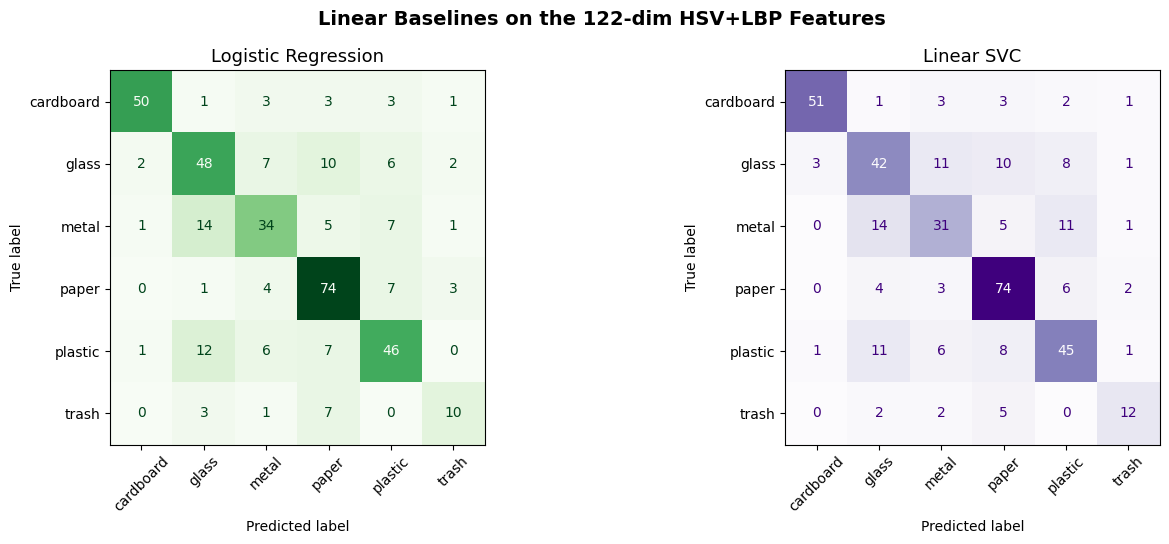

Saved: linear_baseline_confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (name, cm), cmap in zip(axes, confusion_matrices.items(), ['Greens', 'Purples']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=13)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Linear Baselines on the 122-dim HSV+LBP Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'linear_baseline_confusion_matrices.png'), dpi=150)
plt.show()
print("Saved: linear_baseline_confusion_matrices.png")

In [12]:
# Finding 1 claims the glass/metal confusion is a property of the feature space rather than
# of any one classifier. A linear model on the same features is a third inductive bias to
# test that against.

glass_i, metal_i = CLASS_ORDER.index('glass'), CLASS_ORDER.index('metal')

print(f"{'Model':<22} {'glass->metal':>13} {'metal->glass':>13} {'total':>7}")
print("-" * 58)

for slug, name in [('rf', 'Random Forest'), ('mlp', 'MLP')]:
    cm = np.load(os.path.join(RESULTS_PATH, f'{slug}_confusion_matrix.npy'))
    print(f"{name:<22} {cm[glass_i, metal_i]:>13d} {cm[metal_i, glass_i]:>13d} "
          f"{cm[glass_i, metal_i] + cm[metal_i, glass_i]:>7d}")

for name, cm in confusion_matrices.items():
    print(f"{name:<22} {cm[glass_i, metal_i]:>13d} {cm[metal_i, glass_i]:>13d} "
          f"{cm[glass_i, metal_i] + cm[metal_i, glass_i]:>7d}")

Model                   glass->metal  metal->glass   total
----------------------------------------------------------
Random Forest                      8             8      16
MLP                               10             7      17
Logistic Regression                7            14      21
Linear SVC                        11            14      25


### Industrial metrics

In [13]:
industrial = {}

for name, (slug, _) in MODELS.items():
    metrics_df = compute_industrial_metrics(confusion_matrices[name], CLASS_ORDER)
    industrial[name] = metrics_df

    metrics_df.to_csv(os.path.join(RESULTS_PATH, f'{slug}_industrial_metrics.csv'),
                      index=False)

    print(f"=== {name} Industrial Metrics ===")
    print(metrics_df.to_string(index=False))
    print()

print("Saved: logreg_industrial_metrics.csv, linsvc_industrial_metrics.csv")

=== Logistic Regression Industrial Metrics ===
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  50   4  11  0.9259 0.8197    0.7692
    glass  48  31  27  0.6076 0.6400    0.4528
    metal  34  21  28  0.6182 0.5484    0.4096
    paper  74  32  15  0.6981 0.8315    0.6116
  plastic  46  23  26  0.6667 0.6389    0.4842
    trash  10   7  11  0.5882 0.4762    0.3571

=== Linear SVC Industrial Metrics ===
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  51   4  10  0.9273 0.8361    0.7846
    glass  42  32  33  0.5676 0.5600    0.3925
    metal  31  25  31  0.5536 0.5000    0.3563
    paper  74  31  15  0.7048 0.8315    0.6167
  plastic  45  27  27  0.6250 0.6250    0.4545
    trash  12   6   9  0.6667 0.5714    0.4444

Saved: logreg_industrial_metrics.csv, linsvc_industrial_metrics.csv


In [14]:
print("=== Macro-Averaged Industrial Metrics ===")
print(f"{'Metric':<12} {'Logistic Regression':>21} {'Linear SVC':>12}")
print("-" * 47)

for metric in ['Purity', 'Yield', 'Recovery']:
    print(f"{metric:<12} {industrial['Logistic Regression'][metric].mean():>21.4f} "
          f"{industrial['Linear SVC'][metric].mean():>12.4f}")

=== Macro-Averaged Industrial Metrics ===
Metric         Logistic Regression   Linear SVC
-----------------------------------------------
Purity                      0.6841       0.6742
Yield                       0.6591       0.6540
Recovery                    0.5141       0.5082


In [15]:
# Prints the row in the exact format of the README results table so the numbers cannot be
# transcribed wrongly

print("--- README results table rows ---\n")

for name in MODELS:
    y_pred = predictions[name]
    m = industrial[name]
    print(
        f"| {name} "
        f"| {accuracy_score(y_test, y_pred) * 100:.2f}% "
        f"| {f1_score(y_test, y_pred, average='weighted'):.4f} "
        f"| {f1_score(y_test, y_pred, average='macro'):.4f} "
        f"| {m['Purity'].mean():.4f} "
        f"| {m['Yield'].mean():.4f} "
        f"| {m['Recovery'].mean():.4f} |"
    )

--- README results table rows ---

| Logistic Regression | 68.95% | 0.6879 | 0.6687 | 0.6841 | 0.6591 | 0.5141 |
| Linear SVC | 67.11% | 0.6693 | 0.6620 | 0.6742 | 0.6540 | 0.5082 |


In [16]:
# Decomposes the 54-point baseline-to-RF jump into the part the descriptor explains and the
# part non-linearity explains. Reads the committed comparison table rather than the accuracy
# text files, which are not all written in the same format.

master = pd.read_csv(os.path.join(RESULTS_PATH, 'master_comparison.csv')).set_index('Model')
baseline_accuracy = float(master.loc['Baseline', 'Accuracy'])
rf_accuracy = float(master.loc['Random Forest', 'Accuracy'])

best_linear_name = max(MODELS, key=lambda n: accuracy_score(y_test, predictions[n]))
best_linear = accuracy_score(y_test, predictions[best_linear_name])

print(f"{'Rule-based HSV baseline (3 channel means, thresholds)':<54} {baseline_accuracy*100:>6.2f}%")
print(f"{'Best linear model on the 122 features (' + best_linear_name + ')':<54} {best_linear*100:>6.2f}%")
print(f"{'Random Forest on the same 122 features':<54} {rf_accuracy*100:>6.2f}%")
print()
print(f"Attributable to the representation: {(best_linear - baseline_accuracy)*100:+.2f} points")
print(f"Attributable to non-linearity:      {(rf_accuracy - best_linear)*100:+.2f} points")
print(f"Total:                              {(rf_accuracy - baseline_accuracy)*100:+.2f} points")

Rule-based HSV baseline (3 channel means, thresholds)   24.50%
Best linear model on the 122 features (Logistic Regression)  68.95%
Random Forest on the same 122 features                  78.95%

Attributable to the representation: +44.45 points
Attributable to non-linearity:      +10.00 points
Total:                              +54.45 points


### The missing corner: channel means with a learned boundary

The comparison so far has three points on it: hand-set thresholds over three channel means
(notebook 03), a learned linear boundary over 122 features, and a Random Forest over the
same 122 features. Reading the gap between the first two as "the descriptor" is not safe,
because two things change across it at once. The input goes from 3 numbers to 122, and the
decision rule goes from thresholds someone chose by hand to a boundary fitted to data.

A logistic regression on the three channel means alone fills the missing corner. It gets
the learned boundary but not the descriptor, so the step from the rule-based baseline to it
isolates the value of learning, and the step from it to the 122-dim logistic regression
isolates the value of the representation.

The three inputs are the weighted means notebook 03 computes, reproduced exactly: bin
indices treated as bin centres over the same 32-bin normalised histograms `src/features.py`
produces, scaled back to the native H, S and V ranges. Nothing is re-extracted from the
images, so this model sees precisely what the thresholds see.

In [17]:
# Reproduces the weighted-mean HSV computation from notebook 03's baseline_classifier,
# vectorised over the whole feature matrix. Same histograms, same bin-centre convention,
# same 180/32 and 256/32 rescaling.

def channel_means(features):
    bins = np.arange(32)
    channels = []

    for start, scale in ((0, 180 / 32), (32, 256 / 32), (64, 256 / 32)):
        block = features[:, start:start + 32]
        weighted = (block * bins).sum(axis=1) / (block.sum(axis=1) + 1e-6) * scale
        channels.append(weighted)

    return np.column_stack(channels)


all_means = channel_means(all_features)
print(f"Channel-mean feature matrix: {all_means.shape}")
print(f"H range: {all_means[:, 0].min():.1f} to {all_means[:, 0].max():.1f}")
print(f"S range: {all_means[:, 1].min():.1f} to {all_means[:, 1].max():.1f}")
print(f"V range: {all_means[:, 2].min():.1f} to {all_means[:, 2].max():.1f}")

Channel-mean feature matrix: (2527, 3)
H range: 5.4 to 94.1
S range: 0.4 to 169.6
V range: 75.5 to 225.5


In [18]:
# Same stratified 70/15/15 split at random_state=42. Splitting the derived matrix with the
# same seed gives row-for-row the same partition as the 122-dim split above.

M_train_val, M_test, my_train_val, my_test = train_test_split(
    all_means, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

M_train, M_val, my_train, my_val = train_test_split(
    M_train_val, my_train_val,
    test_size=0.176,
    random_state=42,
    stratify=my_train_val
)

assert np.array_equal(my_test, y_test), "channel-mean split does not match the 122-dim split"
print(f"Train {M_train.shape[0]}, validation {M_val.shape[0]}, test {M_test.shape[0]}")
print("Test partition matches the one used for every other model.")

Train 1769, validation 378, test 380
Test partition matches the one used for every other model.


In [19]:
print("=== Logistic Regression on 3 channel means ===")
best_c_means = select_c(
    make_logreg, [0.01, 0.1, 1.0, 10.0, 100.0], "channel-means Logistic Regression",
    X=M_train, y=my_train
)

=== Logistic Regression on 3 channel means ===
C=0.01     - Mean weighted F1: 0.3440 (+/- 0.0034)


C=0.1      - Mean weighted F1: 0.3756 (+/- 0.0136)


C=1.0      - Mean weighted F1: 0.3846 (+/- 0.0168)


C=10.0     - Mean weighted F1: 0.3846 (+/- 0.0168)


C=100.0    - Mean weighted F1: 0.3846 (+/- 0.0168)

Highest mean: C=1.0 (0.3846)
Selected channel-means Logistic Regression C: 1.0


In [20]:
means_logreg = make_logreg(best_c_means)
means_logreg.fit(M_train, my_train)

means_pred = means_logreg.predict(M_test)
means_cm = confusion_matrix(my_test, means_pred, labels=CLASS_ORDER)
means_accuracy = accuracy_score(my_test, means_pred)

report_str = classification_report(
    my_test, means_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER
)

print(f"Validation accuracy: {means_logreg.score(M_val, my_val):.4f}\n")
print("=== Channel-means Logistic Regression Test Set Results ===\n")
print(report_str)
print(f"Test accuracy: {means_accuracy:.4f}")
print(f"Weighted F1:   {f1_score(my_test, means_pred, average='weighted'):.4f}")
print(f"Macro F1:      {f1_score(my_test, means_pred, average='macro'):.4f}")

Validation accuracy: 0.3942

=== Channel-means Logistic Regression Test Set Results ===

              precision    recall  f1-score   support

   cardboard       0.56      0.67      0.61        61
       glass       0.20      0.11      0.14        75
       metal       0.47      0.13      0.20        62
       paper       0.39      0.71      0.50        89
     plastic       0.46      0.56      0.50        72
       trash       0.00      0.00      0.00        21

    accuracy                           0.42       380
   macro avg       0.35      0.36      0.33       380
weighted avg       0.38      0.42      0.37       380

Test accuracy: 0.4211
Weighted F1:   0.3712
Macro F1:      0.3261


C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [21]:
means_industrial = compute_industrial_metrics(means_cm, CLASS_ORDER)

print("=== Channel-means Logistic Regression Industrial Metrics ===")
print(means_industrial.to_string(index=False))
print()
for metric in ['Purity', 'Yield', 'Recovery']:
    print(f"Macro {metric:<9} {means_industrial[metric].mean():.4f}")

=== Channel-means Logistic Regression Industrial Metrics ===
    Class  TP  FP  FN  Purity  Yield  Recovery
cardboard  41  32  20  0.5616 0.6721    0.4409
    glass   8  32  67  0.2000 0.1067    0.0748
    metal   8   9  54  0.4706 0.1290    0.1127
    paper  63 100  26  0.3865 0.7079    0.3333
  plastic  40  47  32  0.4598 0.5556    0.3361
    trash   0   0  21  0.0000 0.0000    0.0000

Macro Purity    0.3464
Macro Yield     0.3619
Macro Recovery  0.2163


In [22]:
# Saved under the means_logreg_ prefix, following the logreg_ and linsvc_ naming. This is a
# diagnostic for the decomposition, not a fifth model, so it is deliberately not added to
# master_comparison_all.csv or the master comparison figure.

with open(os.path.join(RESULTS_PATH, 'means_logreg_classification_report.txt'), 'w') as f:
    f.write(report_str)

with open(os.path.join(RESULTS_PATH, 'means_logreg_accuracy.txt'), 'w') as f:
    f.write(str(means_accuracy))

np.save(os.path.join(RESULTS_PATH, 'means_logreg_confusion_matrix.npy'), means_cm)

with open(os.path.join(RESULTS_PATH, 'means_logreg_final_model.pkl'), 'wb') as f:
    pickle.dump(means_logreg, f)

means_industrial.to_csv(
    os.path.join(RESULTS_PATH, 'means_logreg_industrial_metrics.csv'), index=False
)

print("Saved: means_logreg_accuracy.txt, means_logreg_classification_report.txt,")
print("       means_logreg_confusion_matrix.npy, means_logreg_final_model.pkl,")
print("       means_logreg_industrial_metrics.csv")

Saved: means_logreg_accuracy.txt, means_logreg_classification_report.txt,
       means_logreg_confusion_matrix.npy, means_logreg_final_model.pkl,
       means_logreg_industrial_metrics.csv


In [23]:
# Four-step decomposition. Each row changes exactly one thing from the row above it.

logreg_accuracy = accuracy_score(y_test, predictions['Logistic Regression'])

steps = [
    ('Channel means, hand-set thresholds',      '',                          baseline_accuracy),
    ('Channel means, learned linear boundary',  'thresholds become learned', means_accuracy),
    ('Full descriptor, learned linear boundary', '3 features become 122',    logreg_accuracy),
    ('Full descriptor, Random Forest',          'boundary becomes non-linear', rf_accuracy),
]

print(f"{'Step':<42} {'What changes':<28} {'Accuracy':>9} {'Gain':>9}")
print("-" * 92)

previous = None
gains = {}
for label, change, accuracy in steps:
    gain = '' if previous is None else f"{(accuracy - previous) * 100:+.2f}"
    if previous is not None:
        gains[label] = (accuracy - previous) * 100
    print(f"{label:<42} {change:<28} {accuracy*100:>8.2f}% {gain:>9}")
    previous = accuracy

print()
largest = max(gains, key=gains.get)
print(f"Largest single step: {largest} ({gains[largest]:+.2f} points)")
print()
print("README slots:")
print(f"  means_logreg_acc = {means_accuracy*100:.2f}")
print(f"  gain_1 = {(means_accuracy - baseline_accuracy)*100:+.2f}")
print(f"  gain_2 = {(logreg_accuracy - means_accuracy)*100:+.2f}")

Step                                       What changes                  Accuracy      Gain
--------------------------------------------------------------------------------------------
Channel means, hand-set thresholds                                         24.50%          
Channel means, learned linear boundary     thresholds become learned       42.11%    +17.61
Full descriptor, learned linear boundary   3 features become 122           68.95%    +26.84
Full descriptor, Random Forest             boundary becomes non-linear     78.95%    +10.00

Largest single step: Full descriptor, learned linear boundary (+26.84 points)

README slots:
  means_logreg_acc = 42.11
  gain_1 = +17.61
  gain_2 = +26.84
